# Anomaly Detection — Sensor / Data Stream Outliers
### Detectron AI · Module 03

This notebook detects anomalies in a simulated sensor data stream using three
complementary techniques: **Z-score**, **IQR (Tukey fences)**, and **Isolation Forest**
(an unsupervised ML model). It also implements a consensus voting scheme, matching
the live web demo's approach of requiring agreement across multiple detectors.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest

np.random.seed(7)


## 1. Simulate a sensor stream with injected anomalies

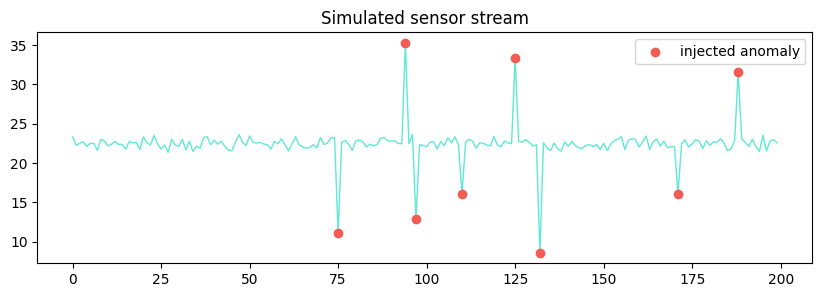

In [2]:
n = 200
baseline = np.random.normal(22.5, 0.5, n)  # e.g. temperature sensor, deg C
anomaly_idx = np.random.choice(n, 8, replace=False)
baseline[anomaly_idx] += np.random.choice([-1, 1], 8) * np.random.uniform(6, 14, 8)

series = pd.Series(baseline, name="sensor_reading")
true_anomaly = np.zeros(n, dtype=bool)
true_anomaly[anomaly_idx] = True

plt.figure(figsize=(10,3))
plt.plot(series, color="#5EEAD4", linewidth=1)
plt.scatter(np.where(true_anomaly)[0], series[true_anomaly], color="#F25C54", zorder=5, label="injected anomaly")
plt.legend(); plt.title("Simulated sensor stream")
plt.show()


## 2. Z-score method

In [3]:
def zscore_outliers(data, threshold=2.5):
    mean, std = data.mean(), data.std()
    z = (data - mean) / std
    return np.abs(z) > threshold, z

z_flags, z_scores = zscore_outliers(series)
print(f"Z-score flagged {z_flags.sum()} points")


Z-score flagged 8 points


## 3. IQR (Tukey fences) method

In [4]:
def iqr_outliers(data):
    q1, q3 = np.percentile(data, [25, 75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5*iqr, q3 + 1.5*iqr
    return (data < lower) | (data > upper), lower, upper

iqr_flags, lower, upper = iqr_outliers(series)
print(f"IQR fences: [{lower:.2f}, {upper:.2f}] -> flagged {iqr_flags.sum()} points")


IQR fences: [21.07, 23.87] -> flagged 8 points


## 4. Isolation Forest (unsupervised ML)

Isolation Forest isolates anomalies by randomly partitioning the feature space — anomalies require fewer splits to isolate, since they sit far from the dense baseline cluster.

In [5]:
iso = IsolationForest(contamination=0.05, random_state=42)
iso_pred = iso.fit_predict(series.values.reshape(-1, 1))
iso_flags = iso_pred == -1
print(f"Isolation Forest flagged {iso_flags.sum()} points")


Isolation Forest flagged 10 points


## 5. Consensus voting across all three methods

In [6]:
votes = z_flags.astype(int) + iqr_flags.astype(int) + iso_flags.astype(int)
consensus = votes >= 2

print(f"Consensus anomalies (>=2 methods agree): {consensus.sum()}")
print(f"True anomalies injected: {true_anomaly.sum()}")
print(f"Correctly identified: {(consensus & true_anomaly).sum()} / {true_anomaly.sum()}")


Consensus anomalies (>=2 methods agree): 8
True anomalies injected: 8
Correctly identified: 8 / 8


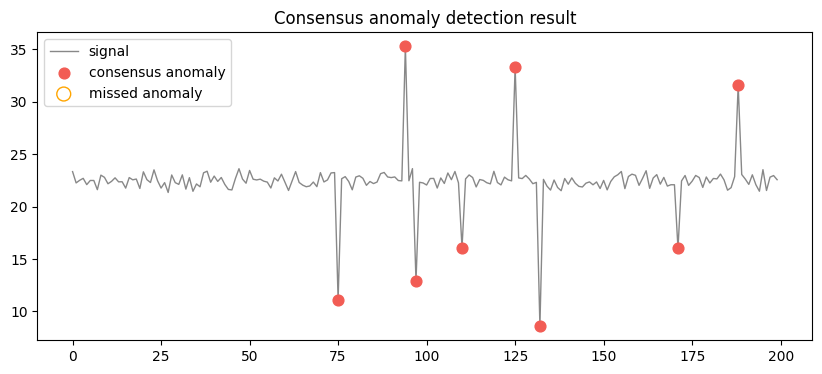

In [7]:
plt.figure(figsize=(10,4))
plt.plot(series, color="#888", linewidth=1, label="signal")
plt.scatter(np.where(consensus)[0], series[consensus], color="#F25C54", s=60, label="consensus anomaly", zorder=5)
plt.scatter(np.where(true_anomaly & ~consensus)[0], series[true_anomaly & ~consensus],
            facecolors='none', edgecolors='orange', s=100, label="missed anomaly", zorder=5)
plt.legend(); plt.title("Consensus anomaly detection result")
plt.show()


## Notes

- The live web demo implements the Z-score, IQR, and rolling-window-deviation methods
  directly in JavaScript (no Isolation Forest, since that needs a trained model) and
  uses the same 2-of-3 consensus voting rule shown here.
- Isolation Forest scales well to high-dimensional, large data streams where simple
  statistical thresholds break down — a natural next step for production sensor networks.
